 ### Student name: Kristyan Connolly

 ### Student ID: 25245295

 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import manifold #needed for multidimensional scaling (MDS) and t-SNE
from sklearn import cluster #needed for k-Means clustering
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder #needed for data preparation

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config

from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score


## Task 1: 

Data Preparation Pipeline
Open a new Jupyter notebook and name it etivity2.ipynb. In this notebook, create a data preparation pipeline that applies the same kind of transformations that you applied as part of e-tivity 1. It is OK to leave some of the transformations outside the pipeline but aim at including as many transformations as you can within the pipeline. Follow the notebook Tutorial 2 - Clustering and Manifold Learning.ipynb as an example.

In [47]:
# First lets load the data into a dataframe
df = pd.read_csv('./bank.csv')


In [48]:
# Print first 5 rows of the dataframe
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [49]:
# Frequency counts for categorical attributes
categorical_attributes  = df.select_dtypes(include=['str']).columns

print("\nCategorical attributes:\n")
print(list(categorical_attributes))

print("\nFrequency counts for categorical attributes:\n")

for column in categorical_attributes: 
    print("\n")
    print(df[column].value_counts(dropna=False))
    print("--------------------------------")


print("\nSummary statistics for numeric attributes:\n")

df.describe()


Categorical attributes:

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'subscribed']

Frequency counts for categorical attributes:



job
management       461
technician       348
blue-collar      298
admin.           247
services         165
retired          162
student           96
unemployed        69
self-employed     64
entrepreneur      45
housemaid         35
NaN               10
Name: count, dtype: int64
--------------------------------


marital
married     1111
single       674
divorced     215
Name: count, dtype: int64
--------------------------------


education
secondary    995
tertiary     684
primary      217
NaN          104
Name: count, dtype: int64
--------------------------------


default
no     1985
yes      15
Name: count, dtype: int64
--------------------------------


housing
no     1037
yes     963
Name: count, dtype: int64
--------------------------------


loan
no     1750
yes     250
Name: count, dtype: int64


,age,balance,day,duration,campaign,pdays,previous
count,1988.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,41.753018,1413.663500,13.851500,292.020500,1.909500,167.896000,2.561500
std,12.724358,3131.224213,9.712189,221.557295,1.378862,131.754126,3.400735
min,18.000000,-980.000000,1.000000,7.000000,1.000000,-1.000000,0.000000
25%,32.000000,201.500000,5.000000,146.000000,1.000000,75.750000,1.000000
50%,38.000000,551.000000,12.000000,236.000000,1.000000,182.000000,2.000000
75%,50.000000,1644.500000,23.000000,379.000000,2.000000,251.000000,3.000000
max,93.000000,81204.000000,31.000000,1823.000000,11.000000,854.000000,55.000000


In [ ]:

########################################################
# Numeric attributes
#####################################################


# shift and log the balance column to avoid log(0)
# np.log(df['balance'] + abs(min(df['balance'])) + 1)
def log_shift(X):
    X = np.asarray(X, dtype=float)
    min_x = np.min(X, axis=0, keepdims=True)
    # avoid log(0)
    return np.log(X + np.abs(min_x) + 1)

# generic log transformer
log_transformer = FunctionTransformer(log_shift, feature_names_out=(
    lambda transformer, input_features: \
    (transformer, input_features)
))

# Pipeline: robust scale then log on the balance column
balance_pipeline = Pipeline(
    steps=[
        ("scaler", RobustScaler()),
        ("distribution_transform", log_transformer)
    ]
)

# Pipeline: standard scale then impute missing values with median
age_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("imputer", SimpleImputer(strategy='median', missing_values=np.nan))
    ]
)

day_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

duration_pipeline = Pipeline(
    steps=[
        ("scaler", RobustScaler())
    ]
)

campaign_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

previous_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

pdays_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)



########################################################
# Ordinal encoding
#####################################################

education_order = [
    "primary", 
    "secondary", 
    "tertiary"
]

education_encoder = OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=np.nan)

education_encoder.fit_transform(df[['education']])

print(education_encoder.categories_)

education_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", education_encoder)
    ]
)

month_order = [
    "jan", 
    "feb", 
    "mar", 
    "apr", 
    "may", 
    "jun", 
    "jul",
    "aug", 
    "sep", 
    "oct", 
    "nov", 
    "dec"
]

month_encoder = OrdinalEncoder(categories=[month_order])

month_encoder.fit_transform(df[['month']])

print(month_encoder.categories_)

month_pipeline = Pipeline(
    steps=[
        ("encoder", month_encoder)
    ]
)


########################################################
# One-hot encoding
#####################################################
one_hot_encoder = OneHotEncoder()

one_hot_encoder_pipeline = Pipeline(
    steps=[
        ("encoder", one_hot_encoder)
    ]
)

job_pipeline = one_hot_encoder_pipeline

contact_pipeline = one_hot_encoder_pipeline

marital_pipeline = one_hot_encoder_pipeline

housing_pipeline = one_hot_encoder_pipeline

poutcome_pipeline = one_hot_encoder_pipeline

default_pipeline = one_hot_encoder_pipeline

subscribed_pipeline = one_hot_encoder_pipeline

loan_pipeline = one_hot_encoder_pipeline

# Next, we use ColumnTransformer to construct the main preprocessing pipeline which consists of all data preprocessing steps applied to all columns.
# the aim is to replace the transformation from e-tivity 1 with a pipeline

preprocess_pipeline = ColumnTransformer(
  transformers = [("balance", balance_pipeline, ["balance"]),
   ("age", age_pipeline, ["age"]),
   ("education", education_pipeline, ["education"]),
   ("month", month_pipeline, ["month"]),
   ("job", job_pipeline, ["job"]),
   ("contact", contact_pipeline, ["contact"]),
   ("marital", marital_pipeline, ["marital"]),
   ("housing", housing_pipeline, ["housing"]),
   ("poutcome", poutcome_pipeline, ["poutcome"]),
   ("default", default_pipeline, ["default"]),
   ("subscribed", subscribed_pipeline, ["subscribed"]),
   ("day", day_pipeline, ["day"]),
   ("duration", duration_pipeline, ["duration"]),
   ("campaign", campaign_pipeline, ["campaign"]),
   ("previous", previous_pipeline, ["previous"]),
   ("pdays", pdays_pipeline, ["pdays"])]        
)

preprocess_pipeline.fit_transform(df)
 

feature_names_in = preprocess_pipeline.feature_names_in_


feature_names_out = preprocess_pipeline.get_feature_names_out()


print(f"Input features:")
for name in feature_names_in:
    print(f"{name}")


print(f"\nOutput features:")
for name in feature_names_out:
    print(f"{name}")
    
preprocess_pipeline

[array(['primary', 'secondary', 'tertiary'], dtype=object)]
[array(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep',
       'oct', 'nov', 'dec'], dtype=object)]
Input features:
age
job
marital
education
default
balance
housing
loan
contact
day
month
duration
campaign
pdays
previous
poutcome
subscribed

Output features:
balance__FunctionTransformer(feature_names_out=<function <lambda> at 0x79a9900afba0>,
                    func=<function log_shift at 0x79a9900af240>)
balance__['balance']
age__age
education__education
month__month
job__job_admin.
job__job_blue-collar
job__job_entrepreneur
job__job_housemaid
job__job_management
job__job_retired
job__job_self-employed
job__job_services
job__job_student
job__job_technician
job__job_unemployed
job__job_nan
contact__contact_cellular
contact__contact_telephone
contact__contact_nan
marital__marital_divorced
marital__marital_married
marital__marital_single
housing__housing_no
housing__housing_yes
poutcome__poutcome_failure
poutcom

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('balance', ...), ('age', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

## Task 2

Plot the sum of squared distances from the data points in the prepared bank dataset to the centers of the k-Means clusters for various values of k and use the Elbow method to pick the best value of k.
Use the Silhouette Coefficient method to determine the best value of k as well.
Use the best value(s) of k to cluster the prepared bank dataset with k-means. Aim at producing meaningful clustering.
Use MDS and t-SNE for visualising the clusterings. Write a short conclusion about the characteristics of the clusters (max 250 words in a markdown cell).

In [ ]:
# Taken from the tutorial
colors = np.array(['orange', 'blue', 'lime', 'khaki', 'pink', 'green', 'purple'])

# points - a 2D array of (x,y) coordinates of data points
# labels - an array of numeric labels in the interval [0..k-1], one for each point
# centers - a 2D array of (x, y) coordinates of cluster centers
# title - title of the plot
def clustering_scatterplot(points, labels, centers, title):
    
    n_clusters = np.unique(labels).size
    for i in range(n_clusters):
        h = plt.scatter(points[labels==i,0],
                        points[labels==i,1], 
                        c=colors[i%colors.size],
                        label = 'cluster '+str(i))

    # plot the centers of the clusters
    if centers is not None:
        plt.scatter(centers[:,0], centers[:,1], c='r', marker='*', s=500)

    _ = plt.title(title)
    _ = plt.legend()
    _ = plt.xlabel('x')
    _ = plt.ylabel('y')



#run the preprocessing pipeline over the dataset
preprocessed_data = preprocess_pipeline.fit_transform(df)

# calculate the inertia and silhouette score for each k
inertias = []
silhouette_scores = []

# range of k values to test
k_range = range(2,11)

# initialize variables to store the best k value and the maximum silhouette score
max_silhouette_score = 0
best_k = 0

# loop through each k value
for i in k_range:
    kmeans = cluster.KMeans(n_clusters=i, n_init=10, max_iter=300, random_state=42)
    kmeans.fit(preprocessed_data)
    
    silhouette_scr =  silhouette_score(preprocessed_data, kmeans.labels_)
     
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_scr)
    # update the best k value if the current silhouette score is higher than the maximum silhouette score
    if silhouette_scr > max_silhouette_score:
        max_silhouette_score = silhouette_scr
        best_k = i


print("calculated best value of k: ", best_k)
preprocessed_data

calculated best value of k:  2


array([[ 0.66823798, -0.76667698,  2.        , ...,  0.06565025,
        -0.16515265, -0.28010681],
       [ 0.76821994, -0.21641256,  1.        , ...,  0.06565025,
        -0.45928025, -0.26492322],
       [ 0.87396611,  1.35577149,  1.        , ...,  0.06565025,
        -0.45928025,  0.53980687],
       ...,
       [ 0.90780018,  3.08517395,  0.        , ..., -0.65976687,
        -0.75340784, -1.28222352],
       [ 1.54518579,  0.33385186,  0.        , ..., -0.65976687,
        -0.75340784, -1.28222352],
       [ 1.81097763, -0.13780336,  1.        , ...,  0.06565025,
        -0.75340784, -1.28222352]], shape=(2000, 37))

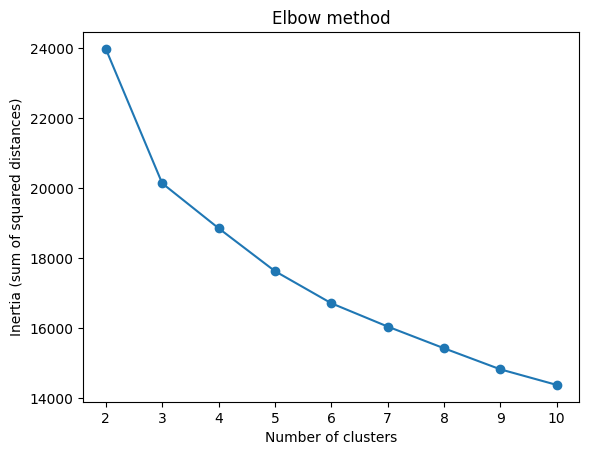

In [70]:
# plot the inertia for each k value
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (sum of squared distances)')
plt.show()


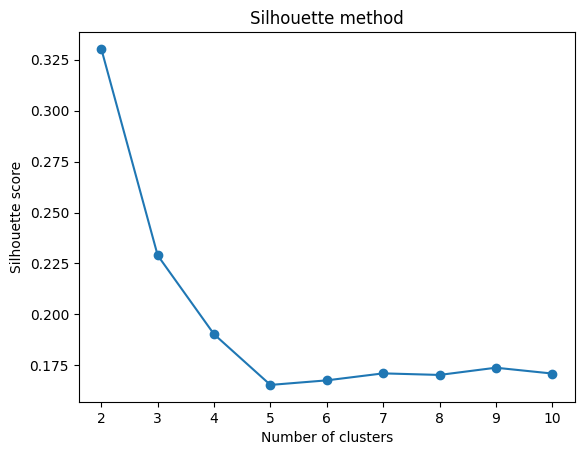

In [71]:

# plot the silhouette score for each k value
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

## K Means

In [89]:
full_pipeline = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("kMeans", cluster.KMeans(n_clusters=best_k, n_init=10, max_iter=300, random_state=42)),
])


clustering_model = full_pipeline.fit(df)


# Here we use the preprocessing step of the pipeline to get a copy of the dataset with the preprocessing steps applied to it.
preprocessed_data = clustering_model['preprocess'].transform(df)#preprocessed_data
data_and_centers = np.r_[preprocessed_data,clustering_model['kMeans'].cluster_centers_]

### MDS 

/home/kris/school/da/data/e-tivity2/myenv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/kris/school/da/data/e-tivity2/myenv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


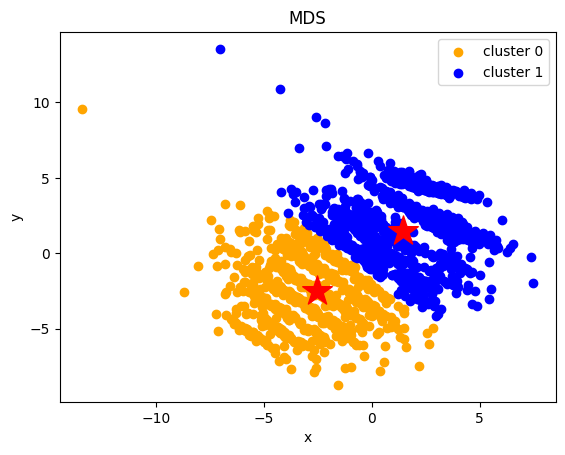

In [90]:

XYcoordinates = manifold.MDS(n_components=2, normalized_stress='auto').fit_transform(data_and_centers)

points = XYcoordinates[:-best_k,:]
labels = clustering_model['kMeans'].labels_
centers = XYcoordinates[-best_k:,:]

clustering_scatterplot(points=XYcoordinates[:-best_k,:], 
                       labels=clustering_model['kMeans'].labels_, 
                       centers=XYcoordinates[-best_k:,:], 
                       title='MDS')

### TSNE

transformation complete


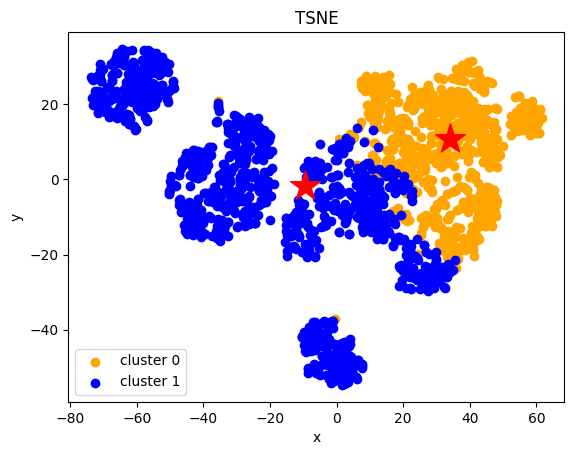

In [78]:
XYcoordinates = manifold.TSNE(n_components=2).fit_transform(data_and_centers)
print("transformation complete")

clustering_scatterplot(points=XYcoordinates[:-best_k,:], 
                       labels=clustering_model['kMeans'].labels_,
                       centers=XYcoordinates[-best_k:,:], 
                       title='TSNE')

In [73]:
df['cluster'] = pd.Series(clustering_model['kMeans'].labels_, index=df.index)
df.describe()

df['cluster'].value_counts()

dfg = df.groupby('cluster')

dfg.head()

#dfg.mean()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed,cluster
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no,1
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no,1
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no,1
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no,1
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no,1
79,38.0,services,married,secondary,no,5000,no,no,cellular,4,dec,720,5,536,5,failure,no,0
80,31.0,admin.,married,secondary,no,389,yes,no,cellular,7,dec,69,1,185,2,failure,no,0
81,42.0,management,married,tertiary,no,144,no,no,cellular,7,dec,143,1,283,3,failure,no,0
82,32.0,admin.,single,secondary,no,8626,no,no,cellular,7,dec,200,1,196,2,failure,no,0
83,57.0,retired,divorced,primary,no,698,no,no,telephone,9,dec,135,3,191,2,failure,no,0


In [74]:
dfg.describe()

age                                                      balance  \
          count       mean        std   min   25%   50%    75%   max   count   
cluster                                                                        
0         740.0  42.551351  14.696158  19.0  31.0  38.0  52.25  93.0   743.0   
1        1248.0  41.279647  11.375187  18.0  33.0  38.5  49.00  86.0  1257.0   

                      ...  pdays        previous                           \
                mean  ...    75%    max    count      mean       std  min   
cluster               ...                                                   
0        1680.685061  ...  186.0  854.0    743.0  2.967699  3.777723  0.0   
1        1255.829753  ...  257.0  648.0   1257.0  2.321400  3.133718  0.0   

                              
         25%  50%  75%   max  
cluster                       
0        1.0  2.0  4.0  55.0  
1        1.0  2.0  3.0  51.0  

[2 rows x 56 columns]

## Task 3

Apply the DBSCAN clustering algorithm to the prepared bank dataset.
Use MDS and t-SNE for visualising the clustering. Write a short conclusion about the characteristics of the clusters and compare the performance of DBSCAN to k-Means. (max 250 words in a markdown cell).

In [97]:
full_pipeline = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("dbscan", cluster.DBSCAN(eps=2.5, min_samples=20)),
])


clustering_model = full_pipeline.fit(df)


print(clustering_model['dbscan'])

# Here we use the preprocessing step of the pipeline to get a copy of the dataset with the preprocessing steps applied to it.
preprocessed_data = clustering_model['preprocess'].transform(df)#preprocessed_data

labels = clustering_model['dbscan'].labels_

print(labels)


DBSCAN(eps=2.5, min_samples=20)
[-1  0  0 ... -1 -1  0]


/home/kris/school/da/data/e-tivity2/myenv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/kris/school/da/data/e-tivity2/myenv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


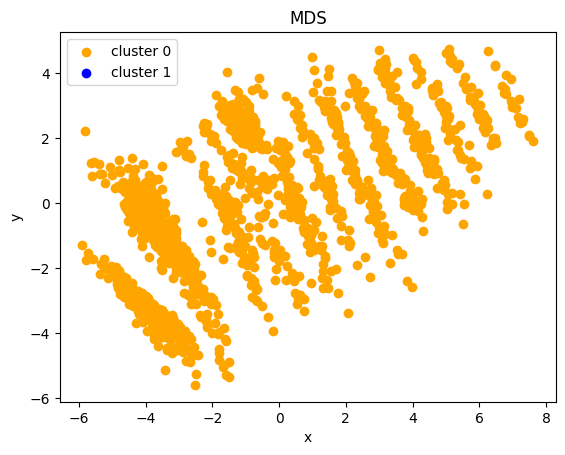

In [99]:
XYcoordinates = manifold.MDS(n_components=2, normalized_stress='auto').fit_transform(preprocessed_data)



clustering_scatterplot(points=XYcoordinates, 
                       labels=labels, 
                       centers=None, 
                       title='MDS')